In [59]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import glob

In [60]:
def load_dataset(data_dir):
    """
    Load dataset from all country directories
    Returns: list of dictionaries with image_path, label_path, and bounding boxes
    """
    dataset = []

    # Get all country directories
    country_dirs = [d for d in os.listdir(data_dir) if d.startswith('country_')]

    for country_dir in country_dirs:
        country_path = os.path.join(data_dir, country_dir)
        images_path = os.path.join(country_path, 'images')
        labels_path = os.path.join(country_path, 'labels')

        # Get all image files
        image_files = glob.glob(os.path.join(images_path, '*.jpg'))

        for image_file in image_files:
            # Get corresponding label file
            base_name = os.path.splitext(os.path.basename(image_file))[0]
            label_file = os.path.join(labels_path, f"{base_name}.txt")

            if os.path.exists(label_file):
                # Read bounding boxes from label file
                bboxes = []
                with open(label_file, 'r') as f:
                    for line in f:
                        line = line.strip()
                        if line:
                            parts = line.split()
                            if len(parts) == 5:
                                class_id = int(parts[0])
                                x_center = float(parts[1])
                                y_center = float(parts[2])
                                width = float(parts[3])
                                height = float(parts[4])
                                bboxes.append(
                                    {
                                        'class_id': class_id,
                                        'x_center': x_center,
                                        'y_center': y_center,
                                        'width': width,
                                        'height': height,
                                    }
                                )

                dataset.append(
                    {'image_path': image_file, 'label_path': label_file, 'bboxes': bboxes, 'country': country_dir}
                )

    return dataset


# Load the dataset
data_dir = "data"
dataset = load_dataset(data_dir)
print(f"Total samples loaded: {len(dataset)}")

# Print sample information
for i, sample in enumerate(dataset[:3]):
    print(f"\nSample {i+1}:")
    print(f"  Image: {sample['image_path']}")
    print(f"  Country: {sample['country']}")
    print(f"  Number of bounding boxes: {len(sample['bboxes'])}")
    if sample['bboxes']:
        print(f"  First bbox: {sample['bboxes'][0]}")

Total samples loaded: 6039

Sample 1:
  Image: data\country_1\images\country1_000014.jpg
  Country: country_1
  Number of bounding boxes: 2
  First bbox: {'class_id': 1, 'x_center': 0.5506944444444445, 'y_center': 0.8472222222222222, 'width': 0.2569444444444444, 'height': 0.225}

Sample 2:
  Image: data\country_1\images\country1_000017.jpg
  Country: country_1
  Number of bounding boxes: 4
  First bbox: {'class_id': 0, 'x_center': 0.34930555555555554, 'y_center': 0.8972222222222223, 'width': 0.12361111111111112, 'height': 0.08888888888888889}

Sample 3:
  Image: data\country_1\images\country1_000027.jpg
  Country: country_1
  Number of bounding boxes: 6
  First bbox: {'class_id': 0, 'x_center': 0.7361111111111112, 'y_center': 0.8270833333333333, 'width': 0.15555555555555556, 'height': 0.07083333333333333}


In [61]:
print(sum([1 for sample in dataset if sample['country'] == 'country_1']))  # Example to count samples from a specific country
print(sum([1 for sample in dataset if sample['country'] == 'country_2']))  # Example to count samples from another country
print(sum([1 for sample in dataset if sample['country'] == 'country_3']))  # Example to count samples from another country

1976
2082
1981


In [62]:
# Define common road damage class names (you can modify based on your dataset)
class_names = {
    0: 'Pothole',
    1: 'Alligator Crack',
    2: 'Transverse Crack',
    3: 'Longitudinal Crack',
}

In [63]:
def convert_yolo_to_bbox(x_center, y_center, width, height, img_width, img_height):
    """
    Convert YOLO format (normalized) to bounding box coordinates
    """
    x_min = (x_center - width / 2) * img_width
    y_min = (y_center - height / 2) * img_height
    x_max = (x_center + width / 2) * img_width
    y_max = (y_center + height / 2) * img_height

    return x_min, y_min, x_max, y_max


def visualize_sample(sample, ax=None, class_names=None):
    """
    Visualize a single sample with bounding boxes
    """
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    # Load and display image
    img = Image.open(sample['image_path'])
    img_width, img_height = img.size
    ax.imshow(img)

    # Define colors for different classes
    colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'pink', 'brown']

    # Draw bounding boxes
    for bbox in sample['bboxes']:
        x_min, y_min, x_max, y_max = convert_yolo_to_bbox(
            bbox['x_center'], bbox['y_center'], bbox['width'], bbox['height'], img_width, img_height
        )

        # Create rectangle patch
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor=colors[bbox['class_id'] % len(colors)],
            facecolor='none',
        )
        ax.add_patch(rect)

        # Add class label
        class_label = (
            f"Class {bbox['class_id']}"
            if class_names is None
            else class_names.get(bbox['class_id'], f"Class {bbox['class_id']}")
        )
        ax.text(
            x_min,
            y_min - 10,
            class_label,
            bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[bbox['class_id'] % len(colors)], alpha=0.8),
            fontsize=10,
            color='white',
            fontweight='bold',
        )

    ax.set_title(
        f"Image: {os.path.basename(sample['image_path'])}\nCountry: {sample['country']}\nBounding Boxes: {len(sample['bboxes'])}"
    )
    ax.axis('off')

    return ax


def visualize_multiple_samples(dataset, n_samples=6, figsize=(20, 15), class_names=None):
    """
    Visualize multiple samples in a grid
    """
    # Sample random images
    samples = random.sample(dataset, min(n_samples, len(dataset)))

    # Calculate grid dimensions
    n_cols = 3
    n_rows = (n_samples + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten() if n_samples > 1 else [axes]

    for i, sample in enumerate(samples):
        visualize_sample(sample, axes[i], class_names)

    # Hide unused subplots
    for i in range(n_samples, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


print("Visualization functions created successfully!")

Visualization functions created successfully!


In [64]:
# Dataset Statistics
print("=== Dataset Statistics ===")
print(f"Total samples: {len(dataset)}")

# Count samples by country
country_counts = {}
class_counts = {}
total_bboxes = 0

for sample in dataset:
    country = sample['country']
    country_counts[country] = country_counts.get(country, 0) + 1
    total_bboxes += len(sample['bboxes'])

    for bbox in sample['bboxes']:
        class_id = bbox['class_id']
        class_counts[class_id] = class_counts.get(class_id, 0) + 1

print(f"\nSamples by country:")
for country, count in sorted(country_counts.items()):
    print(f"  {country}: {count} samples")

print(f"\nTotal bounding boxes: {total_bboxes}")
print(f"Average bounding boxes per image: {total_bboxes/len(dataset):.2f}")

print(f"\nClass distribution:")
for class_id, count in sorted(class_counts.items()):
    class_name = class_names.get(class_id, f"Class {class_id}")
    percentage = (count / total_bboxes) * 100
    print(f"  {class_name}: {count} ({percentage:.1f}%)")

# Filter samples with bounding boxes for visualization
samples_with_bboxes = [sample for sample in dataset if len(sample['bboxes']) > 0]
print(f"\nSamples with bounding boxes: {len(samples_with_bboxes)}")
print(f"Samples without bounding boxes: {len(dataset) - len(samples_with_bboxes)}")

=== Dataset Statistics ===
Total samples: 6039

Samples by country:
  country_1: 1976 samples
  country_2: 2082 samples
  country_3: 1981 samples

Total bounding boxes: 16238
Average bounding boxes per image: 2.69

Class distribution:
  Pothole: 3425 (21.1%)
  Alligator Crack: 3582 (22.1%)
  Transverse Crack: 4280 (26.4%)
  Longitudinal Crack: 4951 (30.5%)

Samples with bounding boxes: 6039
Samples without bounding boxes: 0


=== Random Sample Visualizations ===


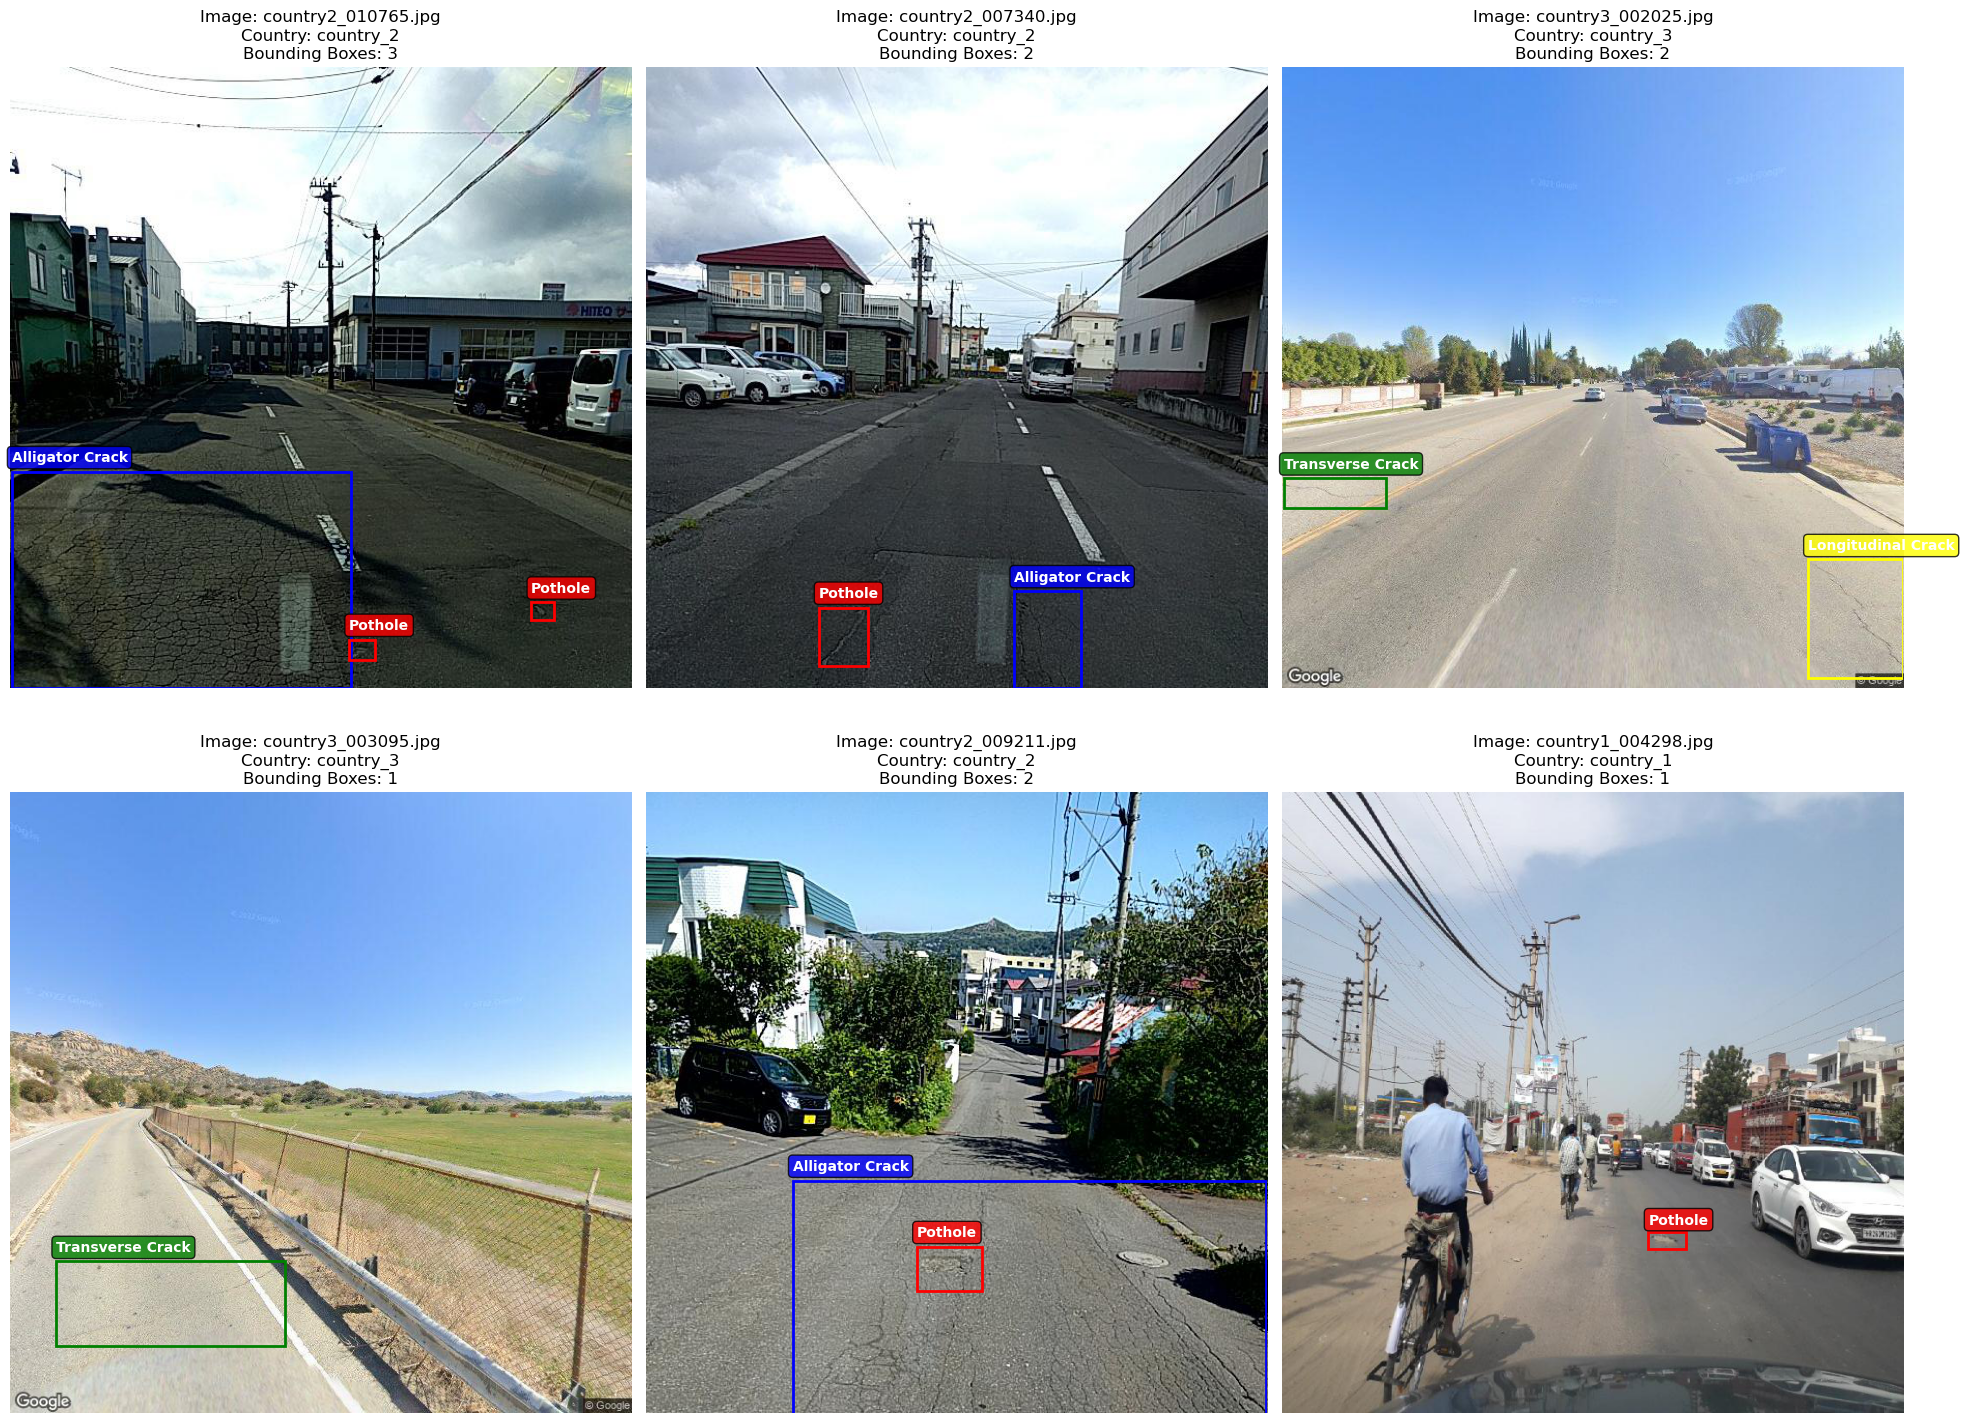

In [65]:
# Visualize random samples from the dataset
print("=== Random Sample Visualizations ===")
visualize_multiple_samples(samples_with_bboxes, n_samples=6, figsize=(20, 15), class_names=class_names)

=== Class-specific Visualizations ===

--- Pothole ---


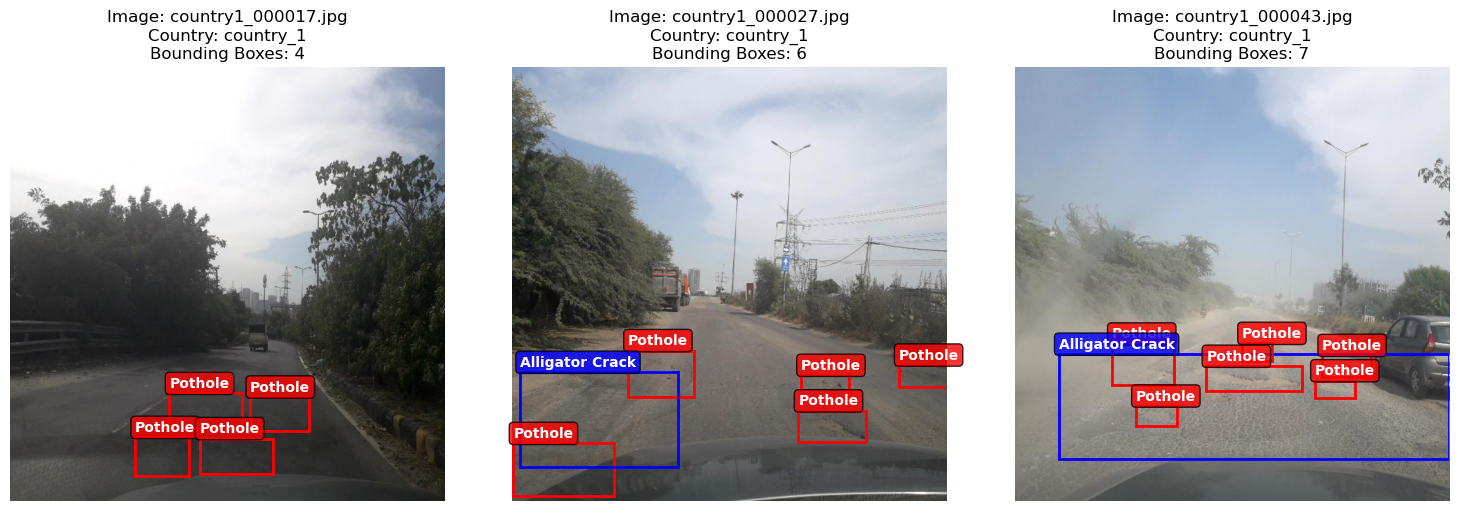


--- Alligator Crack ---


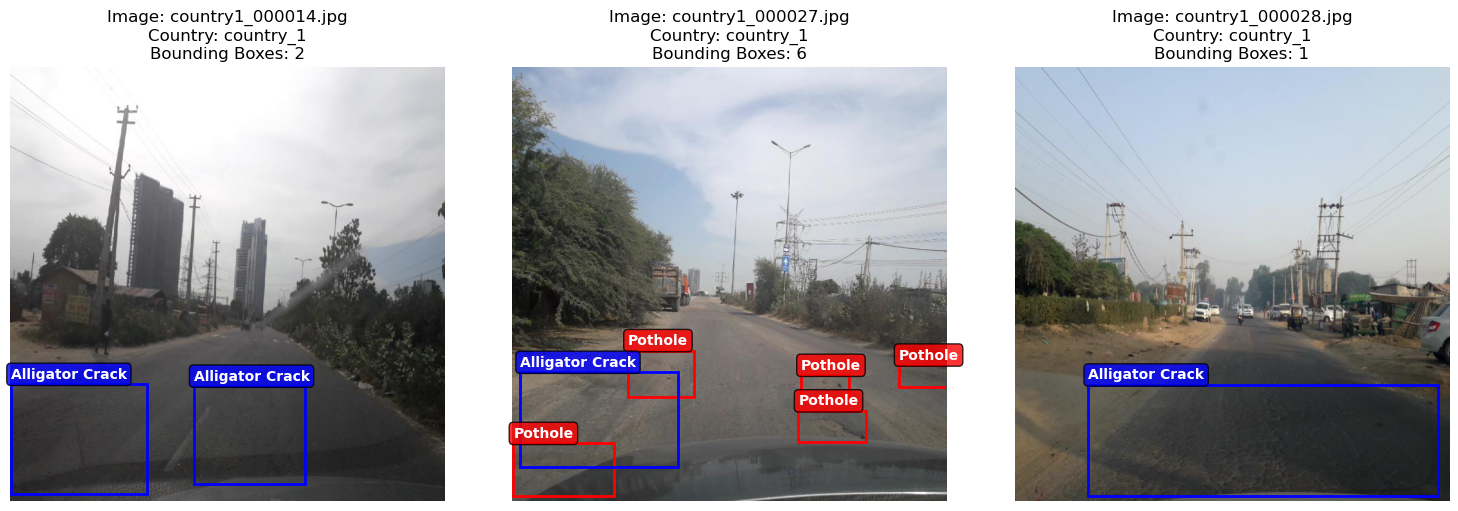


--- Transverse Crack ---


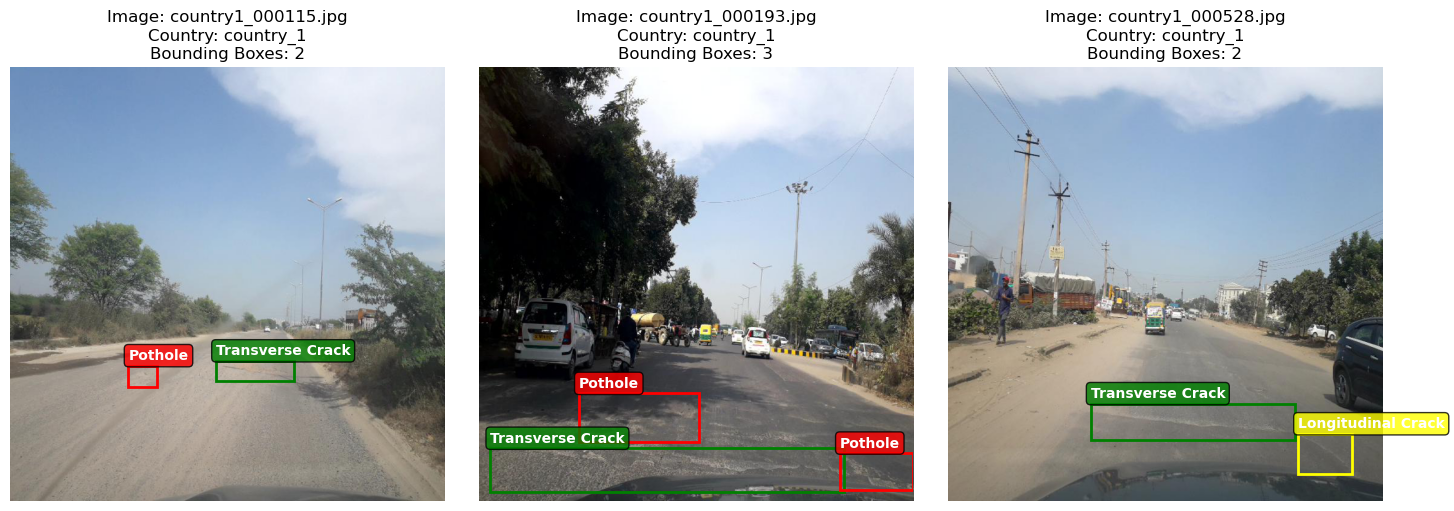


--- Longitudinal Crack ---


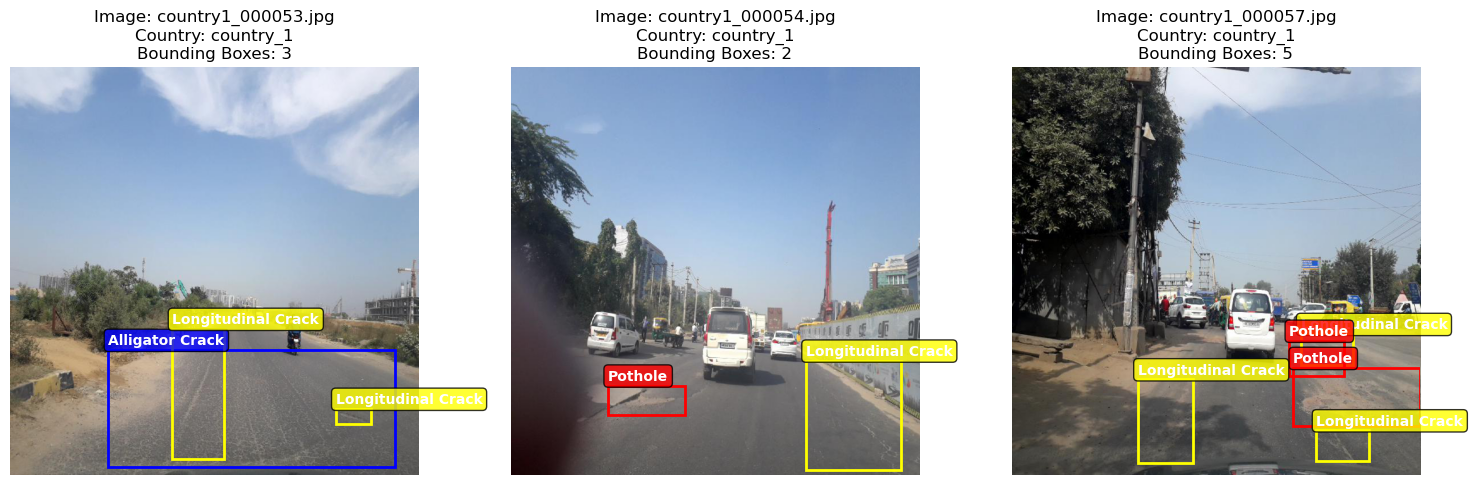

In [66]:
# Visualize samples by specific damage classes
print("=== Class-specific Visualizations ===")


def get_samples_by_class(dataset, target_class_id, max_samples=6):
    """Get samples that contain a specific class"""
    samples = []
    for sample in dataset:
        if any(bbox['class_id'] == target_class_id for bbox in sample['bboxes']):
            samples.append(sample)
        if len(samples) >= max_samples:
            break
    return samples


# Visualize samples for each damage class
for class_id in sorted(class_counts.keys()):
    class_name = class_names.get(class_id, f"Class {class_id}")
    print(f"\n--- {class_name} ---")

    class_samples = get_samples_by_class(samples_with_bboxes, class_id, max_samples=3)

    if class_samples:
        fig, axes = plt.subplots(1, len(class_samples), figsize=(15, 5))
        if len(class_samples) == 1:
            axes = [axes]

        for i, sample in enumerate(class_samples):
            visualize_sample(sample, axes[i], class_names)

        plt.tight_layout()
        plt.show()
    else:
        print(f"No samples found for {class_name}")